In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import geopandas as gpd
from shapely.geometry import Point

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


from last weeks notebook(was having trouble excuting the linear regression model because of how many columns encoded dataset was to big so I did not end up using this)

In [30]:
'''housing_feature = pd.read_csv('CRMLS_Preprocessed_FeatureSpecific.csv')

categorical_cols = housing_feature.select_dtypes(include="object").columns

housing_encoded = pd.get_dummies(housing_feature,columns=categorical_cols,drop_first=True)

print(housing_encoded.shape)

X = housing_encoded.drop(columns=["ClosePrice"])
y = housing_encoded["ClosePrice"]

#time base train/test split
latest_month = housing_encoded["DataMonth"].max()

train = housing_encoded[housing_encoded["DataMonth"] < latest_month]
test  = housing_encoded[housing_encoded["DataMonth"] == latest_month]

X_train = train.drop(columns=["ClosePrice"])
y_train = train["ClosePrice"]

X_test = test.drop(columns=["ClosePrice"])
y_test = test["ClosePrice"]

# Remove DataMonth after splitting since it is no longer needed as a predictor
X_train = X_train.drop(columns=["DataMonth"])
X_test = X_test.drop(columns=["DataMonth"])

numeric_features = X_train.select_dtypes(include="number").columns

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])'''

'housing_feature = pd.read_csv(\'CRMLS_Preprocessed_FeatureSpecific.csv\')\n\ncategorical_cols = housing_feature.select_dtypes(include="object").columns\n\nhousing_encoded = pd.get_dummies(housing_feature,columns=categorical_cols,drop_first=True)\n\nprint(housing_encoded.shape)\n\nX = housing_encoded.drop(columns=["ClosePrice"])\ny = housing_encoded["ClosePrice"]\n\n#time base train/test split\nlatest_month = housing_encoded["DataMonth"].max()\n\ntrain = housing_encoded[housing_encoded["DataMonth"] < latest_month]\ntest  = housing_encoded[housing_encoded["DataMonth"] == latest_month]\n\nX_train = train.drop(columns=["ClosePrice"])\ny_train = train["ClosePrice"]\n\nX_test = test.drop(columns=["ClosePrice"])\ny_test = test["ClosePrice"]\n\n# Remove DataMonth after splitting since it is no longer needed as a predictor\nX_train = X_train.drop(columns=["DataMonth"])\nX_test = X_test.drop(columns=["DataMonth"])\n\nnumeric_features = X_train.select_dtypes(include="number").columns\n\nscaler =

##WEEK 5/7
##PLUS Refining to see why I'm getting low R2

What changed: Log transformed close price made a HUGE differenrce. Since the data is highly skewed it makes sense.

Other things that chnaged: Log transformed other variables, and clipped to 99th percentile for example living area. Alos checked some of the varibles we featured engineered

In [31]:
# Load Data
housing = pd.read_csv("CRMLS_Preprocessed_FeatureSpecific.csv",)

print("Original shape:", housing.shape)


# Make target and time column numeric
housing["ClosePrice"] = pd.to_numeric(housing["ClosePrice"],errors="coerce")

housing["DataMonth"] = pd.to_numeric(housing["DataMonth"],errors="coerce")

# Remove rows that cannot be used
housing = housing.dropna(subset=["ClosePrice", "DataMonth"]).copy()

housing = housing[housing["ClosePrice"] > 0].copy()


# Create date-related features from DataMonth
housing["SaleYear"] = (housing["DataMonth"] // 100).astype("int16")

housing["SaleMonth"] = (housing["DataMonth"] % 100).astype("int8")



# Create useful flooring indicators
flooring_text = (housing["Flooring"].fillna("").astype(str).str.lower())

flooring_types = {
    "HasWoodFloor": "wood",
    "HasTileFloor": "tile",
    "HasCarpetFloor": "carpet",
    "HasLaminateFloor": "laminate",
    "HasVinylFloor": "vinyl",
    "HasConcreteFloor": "concrete"
}

for new_col, keyword in flooring_types.items():
  housing[new_col] = (flooring_text.str.contains(keyword,regex=False).astype("int8"))



# Create useful levels indicators

levels_text = (
    housing["Levels"].fillna("").astype(str).str.lower())

housing["IsOneStory"] = (
    levels_text.str.contains("one",regex=False).astype("int8"))

housing["IsTwoStory"] = (levels_text.str.contains("two",regex=False).astype("int8"))

housing["IsThreeStory"] = (levels_text.str.contains("three",regex=False).astype("int8"))



# Convert important numeric columns
possible_numeric_cols = [
    "Latitude",
    "Longitude",
    "LivingArea",
    "DaysOnMarket",
    "ParkingTotal",
    "LotSizeAcres",
    "YearBuilt",
    "BathroomsTotalInteger",
    "BuildingAreaTotal",
    "BedroomsTotal",
    "BelowGradeFinishedArea",
    "Stories",
    "LotSizeArea",
    "MainLevelBedrooms",
    "GarageSpaces",
    "AssociationFee",
    "LotSizeSquareFeet"
]

for col in possible_numeric_cols:
    if col in housing.columns:
        housing[col] = pd.to_numeric(
            housing[col],
            errors="coerce")


#NEW THINGS FROM WEEK 6
#
# Add unified school district using geographic boundaries


# Load the California school district GeoJSON file
districts = gpd.read_file("DistrictAreasGeoJSON.geojson")

print("School district columns:")
print(districts.columns.tolist())

# Keep only unified school districts
districts = districts[districts["DistrictType"] == "Unified"].copy()

# Keep only the district name and polygon geometry
districts = districts[["DistrictName", "geometry"]].copy()

# Make sure the district boundaries use latitude/longitude coordinates
districts = districts.to_crs("EPSG:4326")


# Create a temporary row identifier so the original order can be restored
housing["_row_id"] = np.arange(len(housing))


# Only create geographic points where coordinates are available
valid_coordinates = (housing["Latitude"].notna() & housing["Longitude"].notna())

housing_valid = housing.loc[valid_coordinates].copy()

housing_geo = gpd.GeoDataFrame(housing_valid,geometry=gpd.points_from_xy(housing_valid["Longitude"],housing_valid["Latitude"]),crs="EPSG:4326")


# Match each property point to the unified school district polygon
housing_geo = gpd.sjoin(
    housing_geo,
    districts,
    how="left",
    predicate="within"
)


# Keep only the new district result from the spatial join
district_mapping = housing_geo[
    ["_row_id", "DistrictName"]].copy()


# Add DistrictName back to the full housing DataFrame
housing = housing.merge(
    district_mapping,
    on="_row_id",
    how="left"
)

housing = housing.drop(
    columns="_row_id"
)

print("\nSchool district mapping.")
print(housing["DistrictName"].value_counts(dropna=False).head(10))
print(
    "Properties without a mapped district:",
    housing["DistrictName"].isna().sum()
)


# Create original engineered features


# Age of property at the time represented by the data
housing["HouseAge"] = (
    housing["SaleYear"] - housing["YearBuilt"])

# Remove impossible house ages
housing.loc[
    (housing["HouseAge"] < 0) |
    (housing["HouseAge"] > 250),
    "HouseAge"] = np.nan


# Bathrooms per bedroom
housing["BathroomsPerBedroom"] = (
    housing["BathroomsTotalInteger"] /
    housing["BedroomsTotal"].replace(0, np.nan))


# Living area per bedroom
housing["LivingAreaPerBedroom"] = (
    housing["LivingArea"] /
    housing["BedroomsTotal"].replace(0, np.nan))


# Lot size relative to living area
housing["LotToLivingAreaRatio"] = (
    housing["LotSizeSquareFeet"] /
    housing["LivingArea"].replace(0, np.nan))


# Parking availability
housing["HasParking"] = (
    housing["ParkingTotal"]
    .fillna(0)
    .gt(0)
    .astype("int8"))


# Garage availability
housing["HasGarage"] = (
    housing["GarageSpaces"]
    .fillna(0)
    .gt(0)
    .astype("int8"))



#  Drop columns that are IDs, raw text, exact dates,
#  redundant, or excessively specific
drop_cols = [
    "CloseDate",
    "ListingContractDate",
    "ContractStatusChangeDate",
    "LotSizeDimensions",
    "BuilderName",
    "SubdivisionName"
]

housing = housing.drop(
    columns=drop_cols,
    errors="ignore"
)

print("Shape after cleaning:", housing.shape)


#SKEWED and looking for outlir
skewed_cols = [
    "LotSizeAcres",
    "LotSizeArea",
    "LivingArea",
    "LotSizeSquareFeet",
    "AssociationFee",
    "ParkingTotal",
    "GarageSpaces"
]

for col in skewed_cols:
    print(f"\n===== {col} =====")
    print(housing[col].describe())
    print("Negative values:", (housing[col] < 0).sum())

outlier_cols = [
    "LotSizeAcres",
    "LotSizeArea",
    "LotSizeSquareFeet",
    "GarageSpaces",
    "ParkingTotal",
    "LivingArea"
]

housing.loc[housing["ParkingTotal"] < 0, "ParkingTotal"] = np.nan
housing.loc[housing["GarageSpaces"] < 0, "GarageSpaces"] = np.nan

#Clip Outliers
for col in outlier_cols:
    upper = housing[col].quantile(0.99)
    housing[col] = housing[col].clip(upper=upper)
print()
print("After clipping:")
for col in skewed_cols:
    print(f"\n===== {col} =====")
    print(housing[col].describe())
    print("Negative values:", (housing[col] < 0).sum())

for col in skewed_cols:
    if col in housing.columns:
        housing[col] = np.log1p(housing[col].clip(lower=0))


# Time-based split
latest_month = housing["DataMonth"].max()

train = housing[housing["DataMonth"] < latest_month].copy()

test = housing[housing["DataMonth"] == latest_month].copy()

print("\nLatest test month:", latest_month)
print("Training rows:", len(train))
print("Testing rows:", len(test))



# Separate predictors and target
y_train = np.log1p(train["ClosePrice"].copy())
y_test = np.log1p(test["ClosePrice"].copy())

X_train_raw = train.drop(columns=["ClosePrice", "DataMonth"],errors="ignore").copy()

X_test_raw = test.drop(columns=["ClosePrice", "DataMonth"],errors="ignore").copy()



# Replace infinity with missing values
X_train_raw = X_train_raw.replace(
    [np.inf, -np.inf],
    np.nan)

X_test_raw = X_test_raw.replace(
    [np.inf, -np.inf],
    np.nan)

# Identify numeric and categorical predictors
numeric_features = X_train_raw.select_dtypes(include=np.number).columns.tolist()

categorical_features = X_train_raw.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumeric columns:", len(numeric_features))
print("Categorical columns:", len(categorical_features))
print("Categorical features:")
print(categorical_features)


# Numeric preprocessing
numeric_pipeline = Pipeline(
    steps=[(
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True)),
        ("scaler",
            StandardScaler())])



# Categorical preprocessing
# min_frequency groups categories seen fewer than 50 times.
# max_categories prevents any one column from creating hundreds or thousands of dummy variables.
categorical_pipeline = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ( "encoder",OneHotEncoder(handle_unknown="infrequent_if_exist",min_frequency=50,max_categories=50,drop="first",dtype=np.float32,sparse_output=True))])



# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric",
          numeric_pipeline,
          numeric_features),
        ("categorical",
          categorical_pipeline,
          categorical_features)],remainder="drop",sparse_threshold=1.0)



# Fit using training data only
X_train = preprocessor.fit_transform(
    X_train_raw
)

X_test = preprocessor.transform(
    X_test_raw
)



# Final checks
print("\nFinal model data")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print(
    "Sparse training matrix:",
    hasattr(X_train, "nnz")
)

if hasattr(X_train, "nnz"):
    density = (
        X_train.nnz /
        (X_train.shape[0] * X_train.shape[1])
    )

    print(f"Matrix density: {density:.4%}")


Original shape: (141892, 54)
School district columns:
['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh', 'GradeLowCensus', 'GradeHighCensus', 'AssistStatus', 'UpdateNotes', 'EnrollTotal', 'EnrollCharter', 'EnrollNonCharter', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAreaSqMi', 'LocaleCode', 'LocaleDesc', 'geometry']

School district mapping.
DistrictName
NaN                     34285
Los Angeles Unified     14188
San Diego Unified        3830
Desert Sands Unified     2609
Capistrano Unified       2593
Palm Springs Unified     2315
Oakland Unified          1850
Long Beach Unified       1758
Corona-Norco Unified     1755
Hemet Unified            1

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 9, 12, 16, 20, 22, 25, 26, 28] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [32]:
categorical_features = X_train_raw.select_dtypes(
    exclude=np.number
).columns.tolist()

In [33]:
model = LinearRegression()
model.fit(X_train,y_train)

#model prediction
y_pred = model.predict(X_test)
r2 = r2_score(y_test,y_pred)

print(f"Linear Regression R2: {r2}")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE: {rmse}\n")

#features using:
print(X_train.shape)

#training rows used
print(f"Training rows used:: {X_train.shape[0]}")

#testing rows used
print(f"\nTesting rows used:: {X_test.shape[0]}")

Linear Regression R2: 0.8234244454730986
RMSE: 0.28740393898012934

(129874, 674)
Training rows used:: 129874

Testing rows used:: 12017


Week 5

In [34]:
tree = DecisionTreeRegressor(max_depth=10,random_state=2026)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

tree_r2 = r2_score(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))

print("Decision Tree R²:", tree_r2)
print("Decision Tree RMSE:", tree_rmse)

Decision Tree R²: 0.7556660821174706
Decision Tree RMSE: 0.33807986483419467


In [35]:
forest = RandomForestRegressor(n_estimators=100,random_state=2026,n_jobs=-1)

forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)

forest_r2 = r2_score(y_test, forest_pred)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_pred))

print("Random Forest R²:", forest_r2)
print("Random Forest RMSE:", forest_rmse)

Random Forest R²: 0.9034257010990251
Random Forest RMSE: 0.21254858035883548


##Week 7 Gradient Boosting

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_booster = GradientBoostingRegressor(n_estimators=250, learning_rate=0.1, max_depth=4, random_state=2026)

gradient_booster.fit(X_train, y_train)

gb_pred = gradient_booster.predict(X_test)

gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print(f"Gradient Boosting R²: {gb_r2}")
print(f"Gradient Boosting RMSE: {gb_rmse}")

Gradient Boosting R²: 0.8777027251671925
Gradient Boosting RMSE: 0.23918603329676816


### XGBoost

In [37]:
from xgboost import XGBRegressor

xgb_booster = XGBRegressor(n_estimators=250, learning_rate=0.1, max_depth=4, random_state=2026, n_jobs=-1)

xgb_booster.fit(X_train, y_train)

xgb_pred = xgb_booster.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"XGBoost R²: {xgb_r2}")
print(f"XGBoost RMSE: {xgb_rmse}")

XGBoost R²: 0.8745834826181926
XGBoost RMSE: 0.24221709717824347


### LightGBM

In [38]:
from lightgbm import LGBMRegressor

lgbm_booster = LGBMRegressor(n_estimators=250, learning_rate=0.1, max_depth=4, random_state=2026, n_jobs=-1)

lgbm_booster.fit(X_train, y_train)

lgbm_pred = lgbm_booster.predict(X_test)

lgbm_r2 = r2_score(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))

print(f"LightGBM R²: {lgbm_r2}")
print(f"LightGBM RMSE: {lgbm_rmse}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.453113 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4857
[LightGBM] [Info] Number of data points in the train set: 129874, number of used features: 671
[LightGBM] [Info] Start training from score 13.777385
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Light Tuning for LightGBM



In [39]:
# Define parameter grids for light tuning
n_estimators_options = [200, 300, 400]
learning_rate_options = [0.05, 0.1, 0.15]
max_depth_options = [3, 4, 5]

best_lgbm_r2 = -np.inf
best_lgbm_rmse = np.inf
best_lgbm_params = {}

for n_est in n_estimators_options:
    for lr in learning_rate_options:
        for md in max_depth_options:
            print(f"\nTrying params: n_estimators={n_est}, learning_rate={lr}, max_depth={md}")
            tuned_lgbm_booster = LGBMRegressor(
                n_estimators=n_est,
                learning_rate=lr,
                max_depth=md,
                random_state=2026,
                n_jobs=-1
            )
            tuned_lgbm_booster.fit(X_train, y_train)
            tuned_lgbm_pred = tuned_lgbm_booster.predict(X_test)

            current_r2 = r2_score(y_test, tuned_lgbm_pred)
            current_rmse = np.sqrt(mean_squared_error(y_test, tuned_lgbm_pred))

            print(f"  R²: {current_r2:.4f}, RMSE: {current_rmse:.4f}")

            if current_r2 > best_lgbm_r2:
                best_lgbm_r2 = current_r2
                best_lgbm_rmse = current_rmse
                best_lgbm_params = {'n_estimators': n_est, 'learning_rate': lr, 'max_depth': md}

print(f"Best LightGBM R²: {best_lgbm_r2:.4f}")
print(f"Best LightGBM RMSE: {best_lgbm_rmse:.4f}")
print(f"Best Parameters: {best_lgbm_params}")

#best score for table
lgbm_r2_tuned = best_lgbm_r2
lgbm_rmse_tuned = best_lgbm_rmse


Trying params: n_estimators=200, learning_rate=0.05, max_depth=3
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4857
[LightGBM] [Info] Number of data points in the train set: 129874, number of used features: 671
[LightGBM] [Info] Start training from score 13.777385
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4857
[LightGBM] [Info] Number of data points in the train set: 129874, number of used features: 671
[LightGBM] [Info] Start training from score 13.777385
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4857
[LightGBM] [Info] Number of data points in the train set: 129874, number of used features: 671
[LightGBM] [Info] Start training from score 13.777385
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Total Bins 4857
[LightGBM] [Info] Number of data points in the train set: 129874, number of used features: 671
[LightGBM] [Info] Start training from score 13.777385
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4857
[LightGBM] [Info] Number of data points in the train set: 129874, number of used features: 671
[LightGBM] [Info] Start training from score 13.777385
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


##RESULTS Data Frame

In [40]:
results_tuned = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM (Untuned)",
        "LightGBM (Tuned)"
    ],
    "R2": [
        r2,
        tree_r2,
        forest_r2,
        gb_r2,
        xgb_r2,
        lgbm_r2,
        lgbm_r2_tuned
    ],
    "RMSE": [
        rmse,
        tree_rmse,
        forest_rmse,
        gb_rmse,
        xgb_rmse,
        lgbm_rmse,
        lgbm_rmse_tuned
    ]
})

# Sort results by r2 score in descending
results_tuned = results_tuned.sort_values(by='R2', ascending=False).reset_index(drop=True)

print(results_tuned)

                Model        R2      RMSE
0    LightGBM (Tuned)  0.905500  0.210253
1       Random Forest  0.903426  0.212549
2   Gradient Boosting  0.877703  0.239186
3             XGBoost  0.874583  0.242217
4  LightGBM (Untuned)  0.872313  0.244400
5   Linear Regression  0.823424  0.287404
6       Decision Tree  0.755666  0.338080


/tmp/ipykernel_1826/1182947187.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='R2', y='Model', data=results_tuned.sort_values(by='R2', ascending=False), palette='viridis')
/tmp/ipykernel_1826/1182947187.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='RMSE', y='Model', data=results_tuned.sort_values(by='RMSE', ascending=True), palette='magma')


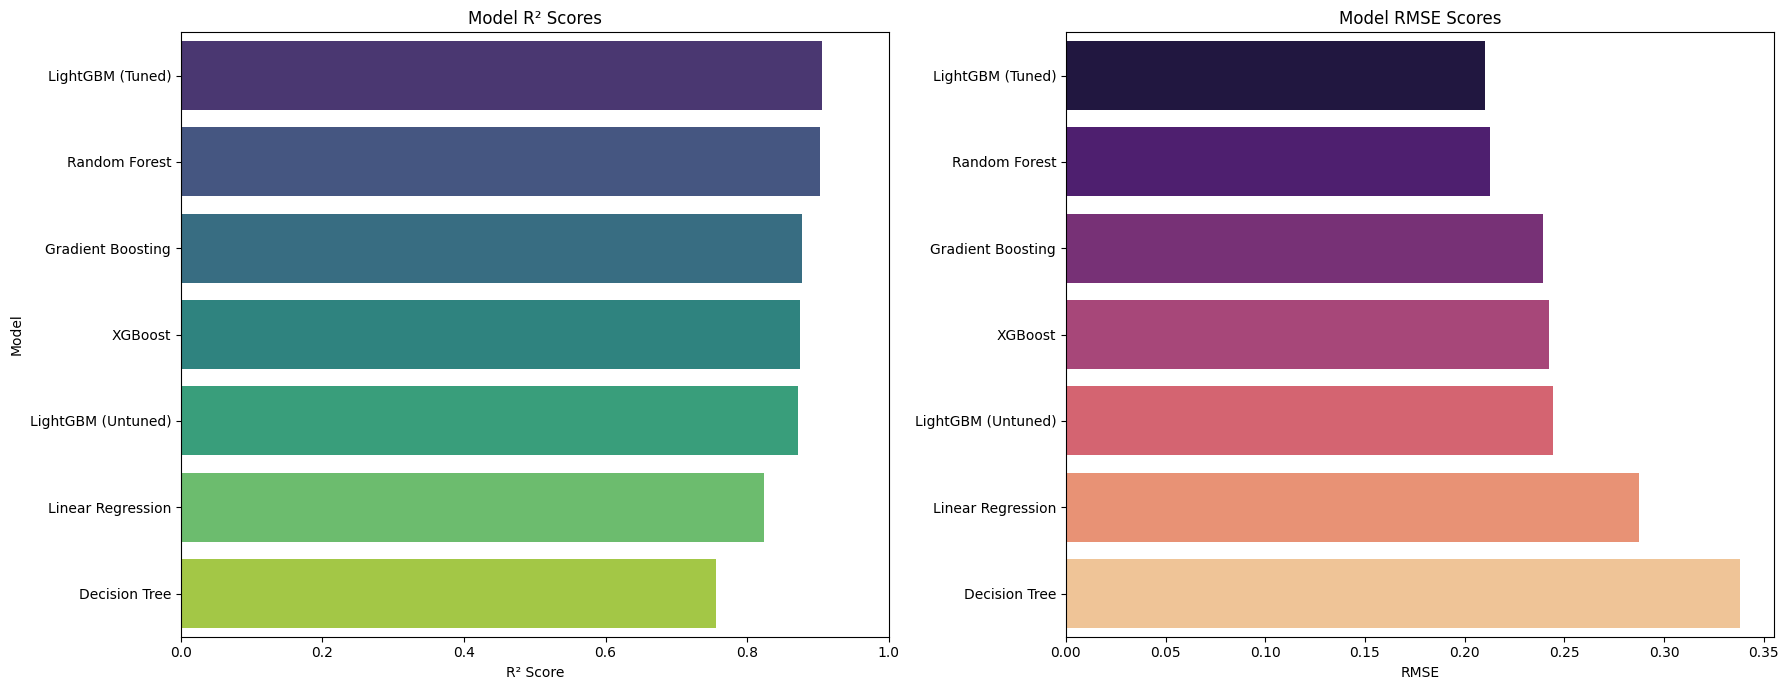

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plotting r2 scores
sns.barplot(ax=axes[0], x='R2', y='Model', data=results_tuned.sort_values(by='R2', ascending=False), palette='viridis')
axes[0].set_title('Model R² Scores')
axes[0].set_xlabel('R² Score')
axes[0].set_ylabel('Model')
axes[0].set_xlim(0, 1)

# Plotting rmse scores
sns.barplot(ax=axes[1], x='RMSE', y='Model', data=results_tuned.sort_values(by='RMSE', ascending=True), palette='magma')
axes[1].set_title('Model RMSE Scores')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()